In [22]:
import numpy as np
from matplotlib import pyplot as plt

Task 1. Simulate a path of the Wiener process. Number of end-points of the grid including $T$ is $N=100$, length of the interval $[0, T]$ in time units is 1, time increment is $\Delta = T/N$. Plot the path.

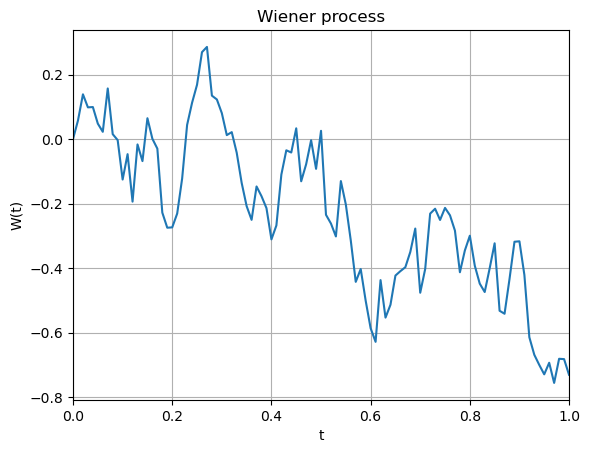

In [23]:
def WienerRandomValue(t):
    return np.sqrt(t) * np.random.normal(0, 1)


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1)
    w_data = np.zeros(N + 1)
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

N = 100
T = 1
t_data, w_data = WienerProcess(N, T)

plt.plot(t_data, w_data)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.xlim(0.0, T)
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 2. Using the random walk algorithm simulate three paths of the Wiener process as the limit of a random walk for different $n=10, 100, 1000$. Plot the paths in one figure, add the legend.

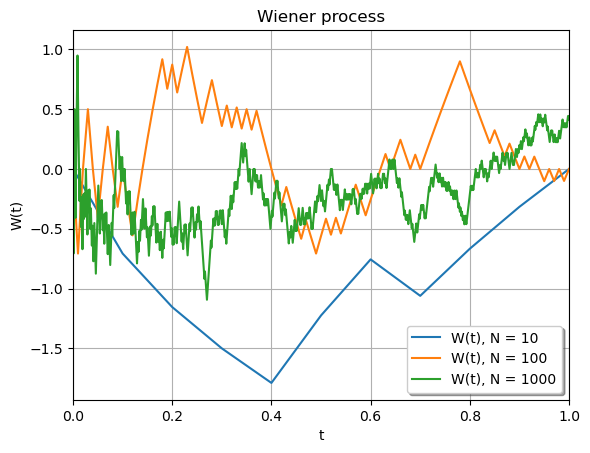

In [24]:
def RandomValueP(p):
    assert p > 0.0 and p < 1.0, '0 < p < 1'

    rand = np.random.uniform(0, 1)
    if rand <= p:
        return 1
    else:
        return -1

def RandomWalk(p, N):
    t_data = np.linspace(0, 1, N + 1)
    w_data = np.zeros(N + 1)
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] * np.sqrt(i / (i + 1)) + RandomValueP(p) / np.sqrt(i + 1)
    return t_data, w_data

p = 0.5
N = [10, 100, 1000]
for k in N:
    t_data, w_data = RandomWalk(p, k)
    plt.plot(t_data, w_data, label = f"W(t), N = {k}")

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 3. Using the the Karhunen-Loeve expansion simulate three paths of the Wiener process with
$n = 10, 50, 100$ terms. Plot the paths in one figure, add legends.

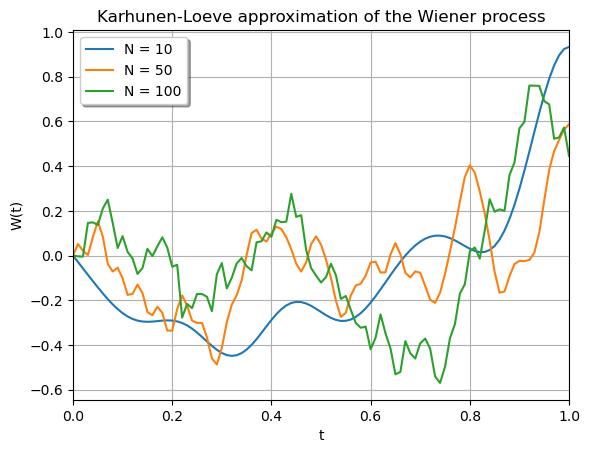

In [25]:
def phi(k, t, T):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def KarhunenLoeveApprox(T, Nt, Nz):
    z_data = np.random.normal(0, 1, size = Nz)
    t_data = np.linspace(0, T, Nt + 1)
    k = np.arange(0, len(z_data)) + 1
    w_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        phi_data = phi(k, t_data[i], T)
        w_data[i] = np.dot(z_data, phi_data)
    return t_data, w_data

T = 1
Nt = 100
Nz = [10, 50, 100]

for k in Nz:
    t_data, w_data = KarhunenLoeveApprox(T, Nt, k)
    plt.plot(t_data, w_data, label = f'N = {k}')

plt.legend(loc = 'upper left', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Karhunen-Loeve approximation of the Wiener process")
plt.grid(True)
plt.show()

Task 4. Plot a trajectory of the geometric Brownian motion obtained from the simulation of the path of the Wiener process, $r=1$ (interest rate) and $\sigma = 0.5$ (volatility).

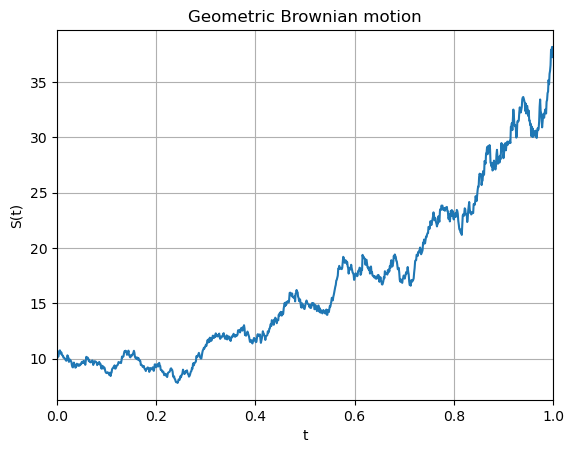

In [26]:
def GeometricBrownianMotion(S0, r, sigma, T):
    Nt = 1000
    t_data = np.linspace(0, T, Nt + 1)
    s_data = np.zeros(Nt + 1)
    s_data[0] = S0
    dt = T / Nt
    for i in range(1, Nt + 1):
        s_data[i] = s_data[i-1] * np.exp((r - sigma**2 / 2)* dt + sigma * WienerRandomValue(dt))
    return t_data, s_data

S0 = 10
r = 1
sigma = 0.5
T = 1

t_data, s_data = GeometricBrownianMotion(S0, r, sigma, T)
plt.plot(t_data, s_data)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("Geometric Brownian motion")
plt.grid(True)
plt.show()

Task 5. Plot a trajectory of the the Brownian bridge starting at $x$ at time $0$ and terminating its run at $y =-1$ at time $T$ obtained from the simulation of the path of the Wiener process. Add markers for start and end points.

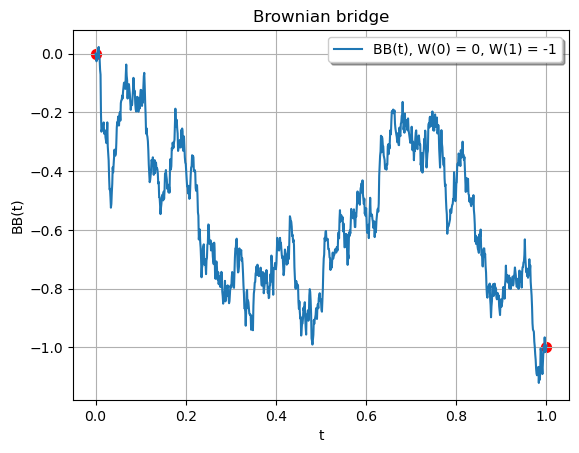

In [27]:
def BrownianBridge(x, y, t0, T):
    Nt = 1000
    t_data, w_data = WienerProcess(Nt, T)
    dt = T/Nt
    bb_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        bb_data[i] = x + w_data[i] - (t_data[i] - t0) / (T - t0) * (w_data[Nt - 1] - y + x)
    return t_data, bb_data

x = 0
y = -1
t0 = 0
T = 1
t_data, bb_data = BrownianBridge(x, y, t0, T)

plt.plot(t_data, bb_data, label = f"BB(t), W({t0}) = {x}, W({T}) = {y}")
plt.scatter ( t0, x, color = "red", s = 50)
plt.scatter ( T, y, color = "red", s = 50)
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("BB(t)")
plt.title("Brownian bridge")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Let us consider a random walk $X = (X_n)_{n \geq 0}$:
$$
X_n = \sum_{k=1}^n \xi_k, \quad \xi_k =
\begin{cases}
1, &\text{with probability $\frac12$}; \\
-1, &\text{with probability $\frac12$}.
\end{cases}
$$
$$
\mathbb{E}\xi_k = 0, \quad \mathrm{Var}\, \xi_k = 1.
$$

Plot $(X_{t_i})_{t_i = \frac{i}{n}}$ so that $t_i$ takes values in $[0,\, 1]$.

In [28]:
def RandomWalk(N, p=[0.5, 0.5]):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=N, p=p)

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)  # Кумулятивная сумма шагов

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Создаем массив t
    t = np.linspace(0, 1, N + 1)  # n + 1 точек для t_i

    # Строим график
    plt.figure(figsize=(10, 5))
    plt.plot(t, X, marker='o', linestyle='-')
    plt.title('Random Walk')
    plt.xlabel('t')
    plt.ylabel('$X_n$')
    plt.grid()
    plt.show()

Exercise 2. Let $H = (H_n)_{n \geq 1}$ be the player's bet at the $n$-th step, i.e. his winnings at this step are equal to $H_n (X_n - X_{n-1}) = H_n \Delta X_n$.

Plot an accumulated winnings of player $Y_n$ at step $n \geq 1$.


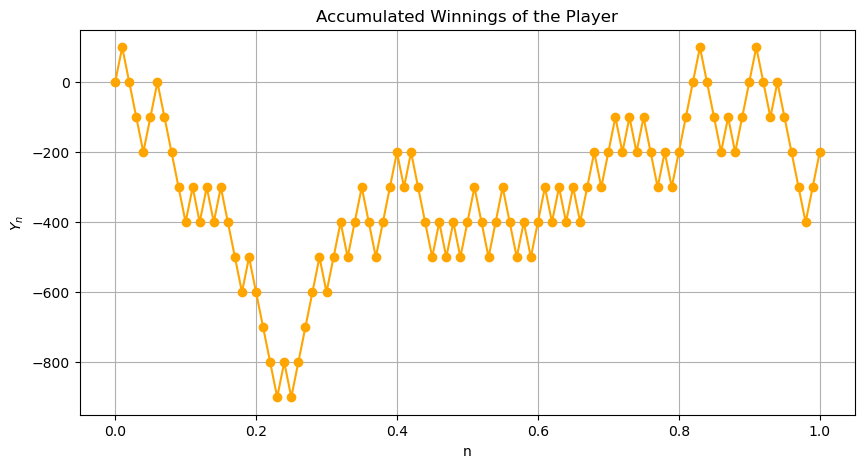

In [29]:
def random_walk_with_bets(n, H):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=n, p=[0.5, 0.5])

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Вычисляем накопленные выигрыши
    Y = np.zeros(n + 1)  # Начинаем с 0
    for i in range(1, n + 1):
        Y[i] = Y[i - 1] + H * (X[i] - X[i - 1])  # Y_n = Y_{n-1} + H * ΔX_n

    # Создаем массив t
    t = np.linspace(0, 1, n + 1)  # n + 1 точек для t_i

    # Строим график накопленных выигрышей
    plt.figure(figsize=(10, 5))
    plt.plot(t, Y, marker='o', linestyle='-', color='orange')
    plt.title('Accumulated Winnings of the Player')
    plt.xlabel('n')
    plt.ylabel('$Y_n$')
    plt.grid()
    plt.show()

# Пример вызова функции с n = 100 и H = 1
random_walk_with_bets(100, H=100)

In [30]:
def generate_ensemble(M, N, T):
    """
    Генерирует ансамбль из M траекторий винеровского процесса.
    
    Параметры:
    M (int): количество траекторий
    N (int): количество шагов (интервалов разбиения)
    T (float): конечное время
    
    Возвращает:
    numpy.ndarray: матрица размером M x (N+1), где каждая строка - траектория
    """
    dt = T / N
    # Генерируем все приращения сразу: M траекторий, N шагов
    # Нормальное распределение с дисперсией dt
    dW = np.random.normal(0, np.sqrt(dt), size=(M, N))
    
    # Вычисляем траектории кумулятивной суммой
    # Начинаем с нуля, добавляем столбец нулей в начало
    W = np.zeros((M, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    
    return W

# Задачи

Задача 1. Квадратичная вариация (Раздел 1.1.2)

Для траектории винеровского процесса при $T=1$ и разного числа интервалов разбиения $\{10,100,1000,10000\}$:

1. Вычислите сумму квадратов приращений $$ S_n= ∑_{k=0}^{n−1}​ ∣W(t_{k+1} )−W(t_k​ )∣^2.$$

2. Постройте график зависимости суммы $S_n$ от числа интервалов разбиения (столбчатую диаграмму).

3. Сделайте выводы.

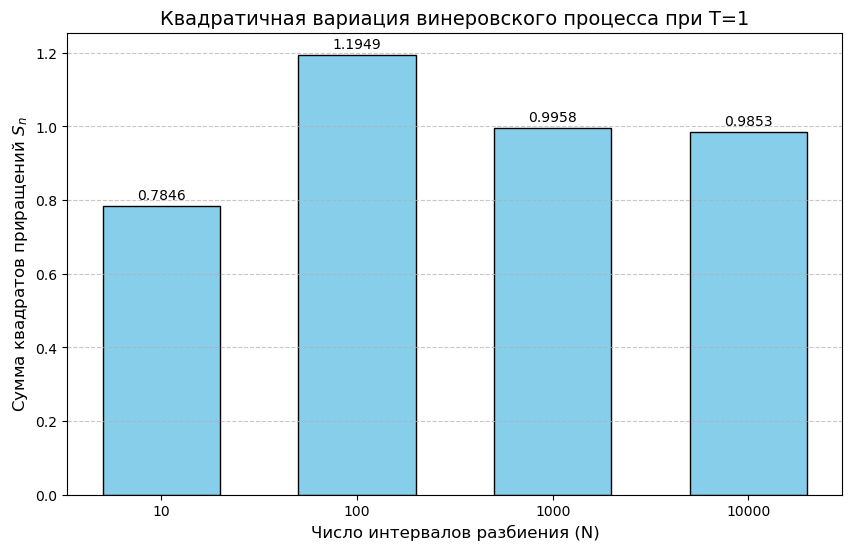

In [31]:
# 1. Вычисляем сумму квадратов приращений S_n для разных n
def quadratic_variation(w_data):
    # Вычисляем приращения: разница между соседними точками
    increments = np.diff(w_data)
    # Возводим приращения в квадрат и суммируем
    sq_var = np.sum(increments**2)
    return sq_var

# Параметры
T = 1
N_values = [10, 100, 1000, 10000]
sq_var_results = []

# Для каждого N генерируем траекторию и вычисляем квадратичную вариацию
for N in N_values:
    # Генерируем траекторию
    t_data, w_data = WienerProcess(N, T)
    sq_var = quadratic_variation(w_data)
    sq_var_results.append(sq_var)

# 2. Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))

# Создаем столбчатую диаграмму.
bars = plt.bar([str(N) for N in N_values], sq_var_results,
               color='skyblue', edgecolor='black', width=0.6)

plt.xlabel('Число интервалов разбиения (N)', fontsize=12)
plt.ylabel('Сумма квадратов приращений $S_n$', fontsize=12)
plt.title('Квадратичная вариация винеровского процесса при T=1', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Добавляем значения сверху столбцов для наглядности
for bar, value in zip(bars, sq_var_results):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom', fontsize=10)

plt.show()

Задача 2. Эмпирическая ковариационная функция (Раздел 1.1.3)

Для винеровского процесса теоретическая ковариация между состояниями в моменты времени $s$ и $t$ равна $\min(s,t)$.

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Вычислите выборочную ковариацию между точками $t=0.5$ и $t=T$ и сравните полученное число с теоретическим значением $0.5$.

3. Сделайте выводы.

In [32]:
# Параметры эксперимента
M = 500  # Количество траекторий в ансамбле
N = 1000 # Число шагов для хорошей точности
T = 1    # Временной интервал
s = 0.5  # Момент времени для ковариации

# Генерируем ансамбль траекторий
print(f"Генерируем ансамбль из {M} траекторий с N={N}...")
ensemble = generate_ensemble(M, N, T)
print("Готово.\n")

# Находим индексы, соответствующие моментам времени s и T
dt = T / N
idx_s = int(s / dt)
idx_T = N

# Извлекаем значения всех траекторий в этих точках
values_at_s = ensemble[:, idx_s]
values_at_T = ensemble[:, idx_T]

# Вычисляем выборочную ковариацию
cov_matrix = np.cov(values_at_s, values_at_T)
empirical_cov = cov_matrix[0, 1]

# Теоретическое значение для винеровского процесса
theoretical_cov = min(s, T)

# Вывод результатов
print(f"Теоретическая ковариация Cov(W({s}), W({T})) = {theoretical_cov}")
print(f"Эмпирическая ковариация (выборка из {M} траекторий) = {empirical_cov:.6f}")
print(f"Разница: {abs(empirical_cov - theoretical_cov):.6f}")

Генерируем ансамбль из 500 траекторий с N=1000...
Готово.

Теоретическая ковариация Cov(W(0.5), W(1)) = 0.5
Эмпирическая ковариация (выборка из 500 траекторий) = 0.526973
Разница: 0.026973


Задача 3. Тестирование мартингального свойства (Раздел 1.1.5)

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Выберите фиксированный момент времени $s=0.4$.

3. Для всех сгенерированных траекторий, проходящих через определенный узкий диапазон значений в момент $s$, вычислите среднее арифметическое их значений в финальный момент $T$.

4. Сравните полученное среднее арифметическое со значением процесса в момент $s$.

5. Сделайте выводы. Проанализовать как диапозон влияет на результат.

In [33]:
# Параметры эксперимента
M = 500
N = 1000
T = 1
s = 0.4

# Генерируем ансамбль траекторий
ensemble = generate_ensemble(M, N, T)

# Находим индексы
dt = T / N
idx_s = int(s / dt)
idx_T = N

# Извлекаем значения
W_s = ensemble[:, idx_s]
W_T = ensemble[:, idx_T]

print("\n--- Результаты для разных размеров диапазона ---")

# Анализируем два диапазона: узкий и широкий
for bandwidth in [0.1, 0.5]:
    center = 0
    lower = center - bandwidth/2
    upper = center + bandwidth/2

    mask = (W_s >= lower) & (W_s <= upper)
    selected_W_s = W_s[mask]
    selected_W_T = W_T[mask]

    if len(selected_W_T) > 0:
        mean_at_T = np.mean(selected_W_T)
        print(f"Диапазон [{lower:.2f}, {upper:.2f}]: "
              f"траекторий = {len(selected_W_T):3d}, "
              f"среднее W(T) = {mean_at_T:+.6f}, "
              f"ожидаемое W(s) ≈ {center:+.1f}, "
              f"разница = {abs(mean_at_T - center):.6f}")
    else:
        print(f"Диапазон [{lower:.2f}, {upper:.2f}]: нет траекторий.")


--- Результаты для разных размеров диапазона ---
Диапазон [-0.05, 0.05]: траекторий =  32, среднее W(T) = -0.239792, ожидаемое W(s) ≈ +0.0, разница = 0.239792
Диапазон [-0.25, 0.25]: траекторий = 156, среднее W(T) = +0.012821, ожидаемое W(s) ≈ +0.0, разница = 0.012821


Задача 4. Анализ независимости приращений (Раздел 1.2)

1. Выберите два непересекающихся интервала $[t_1, t_2​]$ и $[t_3, t_4​]$.
2. Сгенерируйте $M$ траекторий и вычислите приращения
$ΔW_1 =W(t_2)−W(t_1)$ и $ΔW_2 =W(t_4)−W(t_3)$.

3. Постройте диаграмму рассеяния (scatter plot) для $(ΔW_1, ΔW_2)$ и вычислите коэффициент корреляции.

4. Сравните полученное значение с нулем и сделайте выводы.

In [34]:
# 1. Выбираем два непересекающихся интервала
t1, t2 = 0.2, 0.4
t3, t4 = 0.6, 0.8

# Параметры эксперимента
M = 1000
N = 1000
T = 1

# Генерируем ансамбль траекторий
ensemble = generate_ensemble(M, N, T)

# Находим индексы
dt = T / N
idx_t1, idx_t2 = int(t1/dt), int(t2/dt)
idx_t3, idx_t4 = int(t3/dt), int(t4/dt)

# Вычисляем приращения
dW1 = ensemble[:, idx_t2] - ensemble[:, idx_t1]
dW2 = ensemble[:, idx_t4] - ensemble[:, idx_t3]

# Вычисляем коэффициент корреляции
correlation = np.corrcoef(dW1, dW2)[0, 1]

print(f"\n--- Результаты ---")
print(f"Интервал 1: [{t1}, {t2}], длина = {t2-t1}")
print(f"Интервал 2: [{t3}, {t4}], длина = {t4-t3}")
print(f"Коэффициент корреляции Пирсона: {correlation:.6f}")


--- Результаты ---
Интервал 1: [0.2, 0.4], длина = 0.2
Интервал 2: [0.6, 0.8], длина = 0.20000000000000007
Коэффициент корреляции Пирсона: -0.030374


Задача 5. Точность разложения Карунена-Лоэва (Раздел 1.2.3)

1. Реализуйте аппроксимацию винеровской траектории, используя $n=10, 100, 1000$ слагаемых.
2. Рассчитайте среднеквадратичную ошибку между прямой симуляцией и аппроксимацией Карунена-Лоэва.

3. Постройте график зависимости ошибки при увеличении числа членов ряда $n$.
4. Сделайте выводы.

NB! При сравнении аппроксимации надо брать эталонную аппроксимацию и сравнивать с ней, а не с чистым винеровским процессом (взять 10^4)


Результаты:
n =   10, MSE = 0.009810
n =  100, MSE = 0.001016
n = 1000, MSE = 0.000091


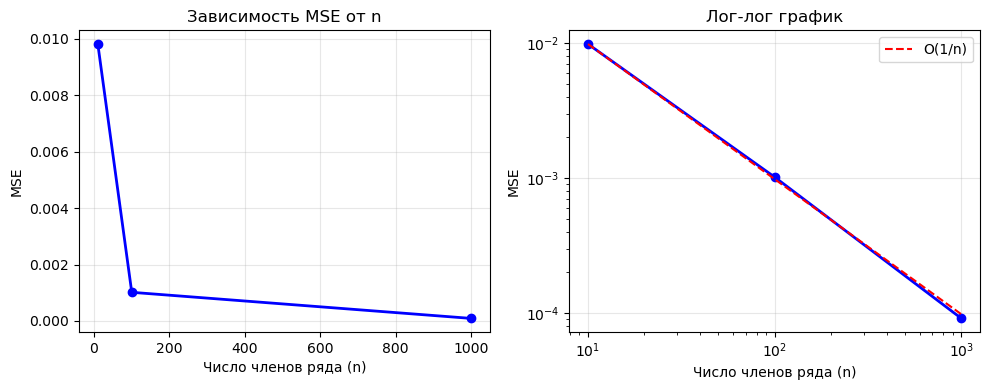

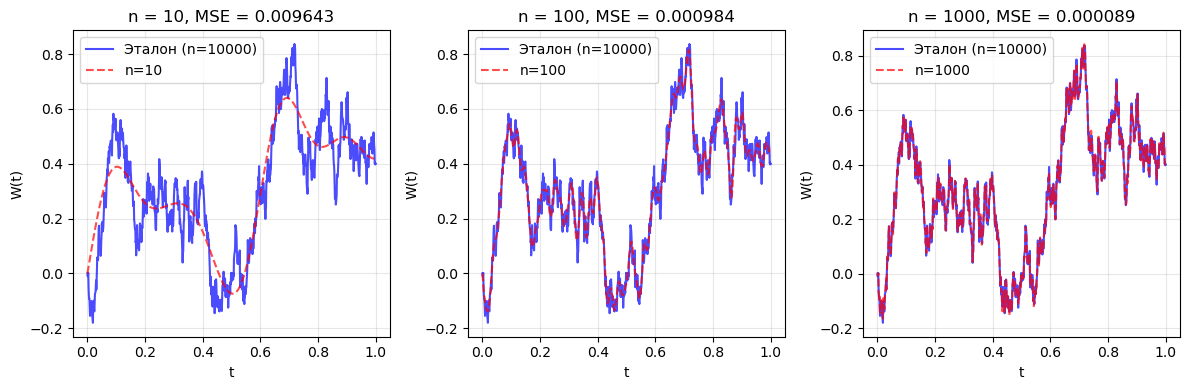

In [35]:
def kl_approximation(T, Nt, n, Z_coeffs=None, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    t = np.linspace(0, T, Nt)
    
    if Z_coeffs is None:
        Z_coeffs = np.random.normal(0, 1, size=n)
    else:
        Z_coeffs = Z_coeffs[:n]
    
    k = np.arange(1, n+1).reshape(-1, 1)
    lambda_k = (2 * T / ((2*k - 1) * np.pi))**2
    phi_k = np.sqrt(2) * np.sin((2*k - 1) * np.pi * t / (2 * T))
    
    W = np.sum(Z_coeffs.reshape(-1, 1) * np.sqrt(lambda_k) * phi_k, axis=0)
    return t, W, Z_coeffs

# Параметры
T = 1.0
Nt = 1000
n_ref = 10000
n_values = [10, 100, 1000]
n_trajectories = 20

# Вычисление ошибок
mse_results = {n: [] for n in n_values}

for traj in range(n_trajectories):
    _, w_ref, Z_ref = kl_approximation(T, Nt, n_ref, seed=traj*100+42)
    
    for n in n_values:
        _, w_n, _ = kl_approximation(T, Nt, n, Z_coeffs=Z_ref)
        mse_results[n].append(np.mean((w_ref - w_n)**2))

# Усреднение
mean_mse = [np.mean(mse_results[n]) for n in n_values]

# Результаты
print("\nРезультаты:")
for n, mse in zip(n_values, mean_mse):
    print(f"n = {n:4d}, MSE = {mse:.6f}")

# График ошибки
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(n_values, mean_mse, 'bo-', linewidth=2)
plt.xlabel('Число членов ряда (n)')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)
plt.title('Зависимость MSE от n')

plt.subplot(1, 2, 2)
plt.loglog(n_values, mean_mse, 'bo-', linewidth=2)
plt.loglog(n_values, [mean_mse[0]*n_values[0]/n for n in n_values], 
           'r--', label='O(1/n)')
plt.xlabel('Число членов ряда (n)')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)
plt.title('Лог-лог график')
plt.legend()

plt.tight_layout()
plt.show()

# Визуализация траекторий
plt.figure(figsize=(12, 4))
t_ref, w_ref, Z_ref = kl_approximation(T, Nt, n_ref, seed=42)

for i, n in enumerate([10, 100, 1000], 1):
    _, w_n, _ = kl_approximation(T, Nt, n, Z_coeffs=Z_ref)
    
    plt.subplot(1, 3, i)
    plt.plot(t_ref, w_ref, 'b-', label=f'Эталон (n={n_ref})', alpha=0.7)
    plt.plot(t_ref, w_n, 'r--', label=f'n={n}', alpha=0.7)
    plt.xlabel('t')
    plt.ylabel('W(t)')
    plt.title(f'n = {n}, MSE = {np.mean((w_ref - w_n)**2):.6f}')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()